In [1]:
import numpy as np
import matplotlib.pyplot as plt

from doppler import calculate_doppler_beta

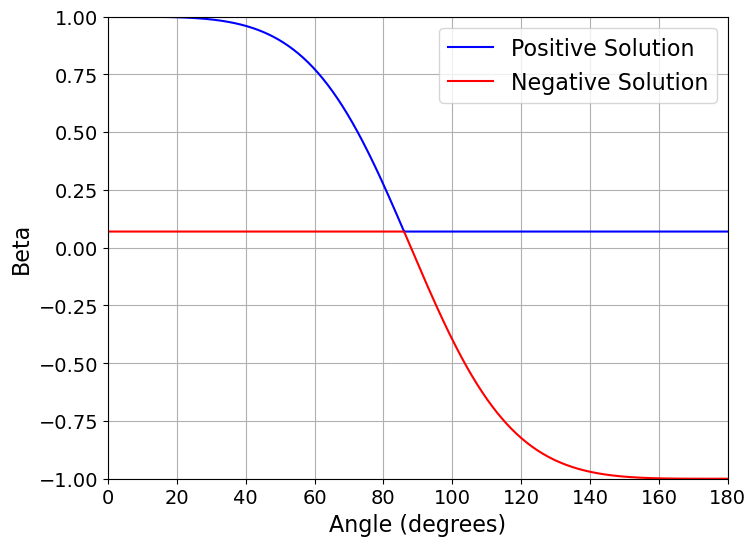

In [2]:
beta_vals1, beta_vals2, theta_vals = calculate_doppler_beta(6.792, energy_offset=0.0, angle_offset=0.0, fixed_beta=0.07)

plt.figure(figsize=(8, 6))
plt.plot(np.rad2deg(theta_vals), beta_vals1, label='Positive Solution', color='blue')
plt.plot(np.rad2deg(theta_vals), beta_vals2, label='Negative Solution', color='red')

plt.xlim(0, 180)
plt.ylim(-1, 1)

plt.xlabel('Angle (degrees)', fontsize=16)
plt.ylabel('Beta', fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid()

plt.legend(fontsize=16)

plt.show()

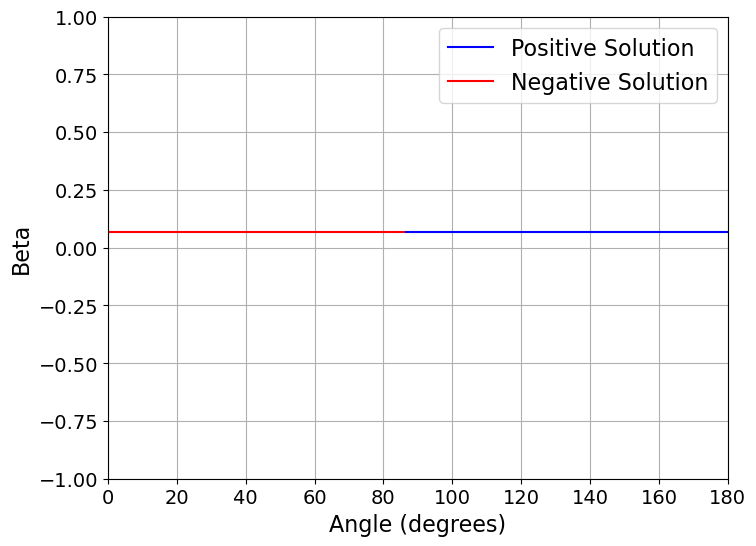

In [3]:
beta_vals1, beta_vals2, theta_vals = calculate_doppler_beta(6.792, energy_offset=0.0, angle_offset=0.0, fixed_beta=0.07)

# mask values with theta > 90 degrees
mask = np.rad2deg(theta_vals) > 86
theta_vals1 = theta_vals[mask]
beta_vals1 = beta_vals1[mask]
beta_vals2 = beta_vals2[~mask]
theta_vals2 = theta_vals[~mask]


plt.figure(figsize=(8, 6))
plt.plot(np.rad2deg(theta_vals1), beta_vals1, label='Positive Solution', color='blue')
plt.plot(np.rad2deg(theta_vals2), beta_vals2, label='Negative Solution', color='red')

plt.xlim(0, 180)
plt.ylim(-1, 1)

plt.xlabel('Angle (degrees)', fontsize=16)
plt.ylabel('Beta', fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.grid()

plt.legend(fontsize=16)

plt.show()

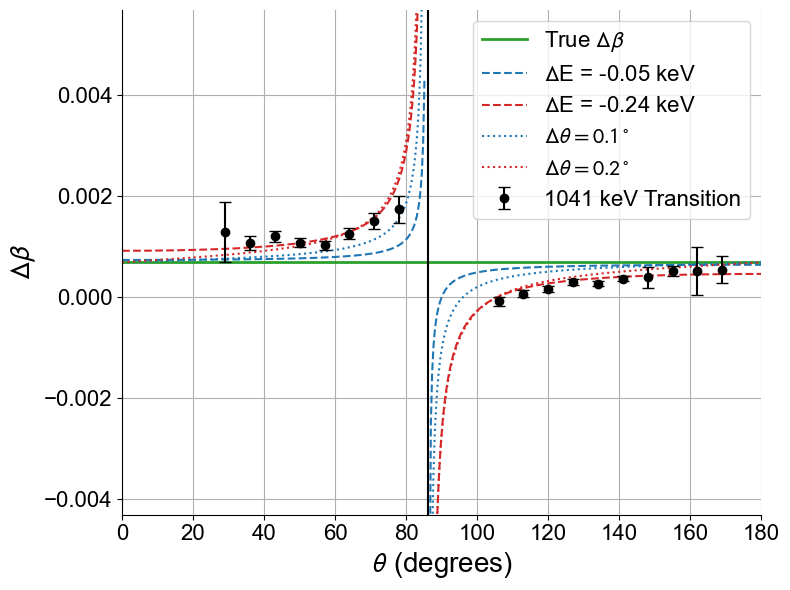

In [23]:
# Nature-specific font settings
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "Liberation Sans"], # Fallback chain
    "pdf.fonttype": 42,        # Ensures text is editable in Illustrator/Inkscape
    "ps.fonttype": 42,
    "mathtext.fontset": "stixsans", # Makes LaTeX math match the sans-serif look
    "axes.labelweight": "normal",
    "axes.titleweight": "normal"
})

def select_solutions(theta_vals, beta_vals1, beta_vals2, theta_cut=86):
    mask = np.rad2deg(theta_vals) > theta_cut
    theta_vals1 = theta_vals[mask]
    beta_vals1 = beta_vals1[mask]
    beta_vals2 = beta_vals2[~mask]
    theta_vals2 = theta_vals[~mask]
    return theta_vals1, beta_vals1, theta_vals2, beta_vals2

delta_beta_ref = 6.87e-4

plt.figure(figsize=(8, 6))

beta_vals1, beta_vals2, theta_vals = calculate_doppler_beta(6792, energy_offset=0.0, angle_offset=0.0, fixed_beta=0.07)
x1, y1, x2, y2 = select_solutions(theta_vals, beta_vals1, beta_vals2)

y1 = y1 - 0.07 + delta_beta_ref
y2 = y2 - 0.07 + delta_beta_ref

plt.plot(np.rad2deg(x1), y1, label=r'True $\Delta \beta$', color='tab:green', lw=2)
plt.plot(np.rad2deg(x2), y2, color='tab:green', lw=2)

beta_vals1, beta_vals2, theta_vals = calculate_doppler_beta(1.041, energy_offset=-0.00005, angle_offset=0.0, fixed_beta=0.07)
x1, y1, x2, y2 = select_solutions(theta_vals, beta_vals1, beta_vals2, theta_cut=86)

y1 = y1 - 0.07 + delta_beta_ref
y2 = y2 - 0.07 + delta_beta_ref

plt.plot(np.rad2deg(x1), y1, label=r'$\Delta$E = -0.05 keV', color='tab:blue', linestyle='--')
plt.plot(np.rad2deg(x2), y2, color='tab:blue', linestyle='--')

beta_vals1, beta_vals2, theta_vals = calculate_doppler_beta(1.041, energy_offset=-0.00024, angle_offset=0.0, fixed_beta=0.07)
x1, y1, x2, y2 = select_solutions(theta_vals, beta_vals1, beta_vals2, theta_cut=86)

y1 = y1 - 0.07 + delta_beta_ref
y2 = y2 - 0.07 + delta_beta_ref

plt.plot(np.rad2deg(x1), y1, label=r'$\Delta$E = -0.24 keV', color='tab:red', linestyle='--')
plt.plot(np.rad2deg(x2), y2, color='tab:red', linestyle='--')

beta_vals1, beta_vals2, theta_vals = calculate_doppler_beta(1.041, energy_offset=0.0, angle_offset=0.1, fixed_beta=0.07)
x1, y1, x2, y2 = select_solutions(theta_vals, beta_vals1, beta_vals2, theta_cut=86)

y1 = y1 - 0.07 + delta_beta_ref
y2 = y2 - 0.07 + delta_beta_ref

plt.plot(np.rad2deg(x1), y1, label=r'$\Delta\theta = 0.1^\circ$', color='tab:blue', linestyle=':')
plt.plot(np.rad2deg(x2), y2, color='tab:blue', linestyle=':')

beta_vals1, beta_vals2, theta_vals = calculate_doppler_beta(1.041, energy_offset=0.0, angle_offset=0.2, fixed_beta=0.07)
x1, y1, x2, y2 = select_solutions(theta_vals, beta_vals1, beta_vals2, theta_cut=86)

y1 = y1 - 0.07 + delta_beta_ref
y2 = y2 - 0.07 + delta_beta_ref

plt.plot(np.rad2deg(x1), y1, label=r'$\Delta\theta = 0.2^\circ$', color='tab:red', linestyle=':')
plt.plot(np.rad2deg(x2), y2, color='tab:red', linestyle=':')

data = np.loadtxt('utils/delta_beta_vs_theta.txt', unpack=True)
theta_data, delta_beta_data, delta_beta_error = data

plt.errorbar(theta_data, delta_beta_data, yerr=delta_beta_error, fmt='o', color='black', label='1041 keV Transition',
             capsize=4, markeredgecolor='black', markeredgewidth=1, zorder=5, elinewidth=1.5)

plt.axvline(86, color='black')

plt.xlim(0, 180)
plt.ylim(-1, 1)

plt.xlabel(r'$\theta$ (degrees)', fontsize=20)
plt.ylabel(r'$\Delta \beta$', fontsize=20)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.ylim(-5e-3 + delta_beta_ref, 5e-3 + delta_beta_ref)

plt.grid()

plt.legend(fontsize=16)

# Remove upper and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('plots/doppler_sensitivity_1041.pdf')
plt.show()

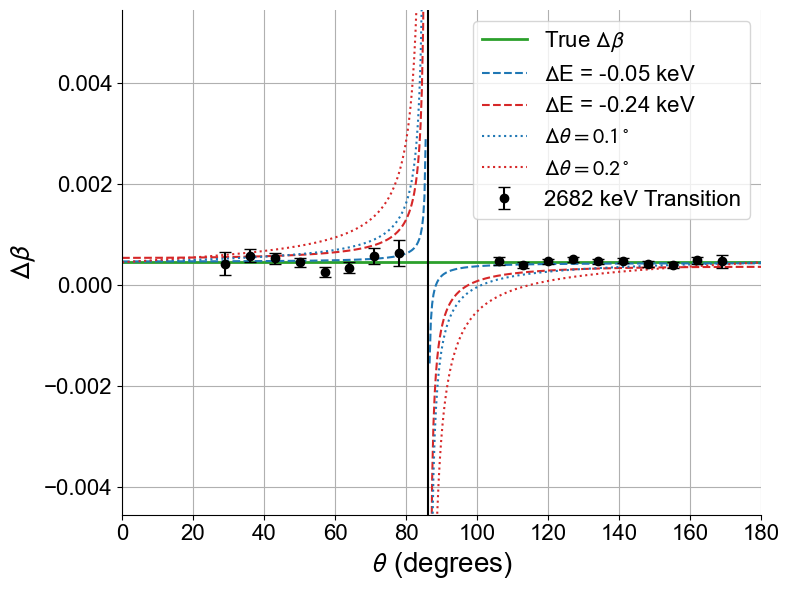

In [21]:
def select_solutions(theta_vals, beta_vals1, beta_vals2, theta_cut=86):
    mask = np.rad2deg(theta_vals) > theta_cut
    theta_vals1 = theta_vals[mask]
    beta_vals1 = beta_vals1[mask]
    beta_vals2 = beta_vals2[~mask]
    theta_vals2 = theta_vals[~mask]
    return theta_vals1, beta_vals1, theta_vals2, beta_vals2

delta_beta_ref = 4.47e-4

plt.figure(figsize=(8, 6))

beta_vals1, beta_vals2, theta_vals = calculate_doppler_beta(2.682, energy_offset=0.0, angle_offset=0.0, fixed_beta=0.07)
x1, y1, x2, y2 = select_solutions(theta_vals, beta_vals1, beta_vals2)

y1 = y1 - 0.07 + delta_beta_ref
y2 = y2 - 0.07 + delta_beta_ref

plt.plot(np.rad2deg(x1), y1, label=r'True $\Delta \beta$', color='tab:green', lw=2)
plt.plot(np.rad2deg(x2), y2, color='tab:green', lw=2)

beta_vals1, beta_vals2, theta_vals = calculate_doppler_beta(2.682, energy_offset=-0.00005, angle_offset=0.0, fixed_beta=0.07)
x1, y1, x2, y2 = select_solutions(theta_vals, beta_vals1, beta_vals2, theta_cut=86)

y1 = y1 - 0.07 + delta_beta_ref
y2 = y2 - 0.07 + delta_beta_ref

plt.plot(np.rad2deg(x1), y1, label=r'$\Delta$E = -0.05 keV', color='tab:blue', linestyle='--')
plt.plot(np.rad2deg(x2), y2, color='tab:blue', linestyle='--')

beta_vals1, beta_vals2, theta_vals = calculate_doppler_beta(2.682, energy_offset=-0.00024, angle_offset=0.0, fixed_beta=0.07)
x1, y1, x2, y2 = select_solutions(theta_vals, beta_vals1, beta_vals2, theta_cut=86)

y1 = y1 - 0.07 + delta_beta_ref
y2 = y2 - 0.07 + delta_beta_ref

plt.plot(np.rad2deg(x1), y1, label=r'$\Delta$E = -0.24 keV', color='tab:red', linestyle='--')
plt.plot(np.rad2deg(x2), y2, color='tab:red', linestyle='--')

beta_vals1, beta_vals2, theta_vals = calculate_doppler_beta(2.682, energy_offset=0.0, angle_offset=0.1, fixed_beta=0.07)
x1, y1, x2, y2 = select_solutions(theta_vals, beta_vals1, beta_vals2, theta_cut=86)

y1 = y1 - 0.07 + delta_beta_ref
y2 = y2 - 0.07 + delta_beta_ref

plt.plot(np.rad2deg(x1), y1, label=r'$\Delta\theta = 0.1^\circ$', color='tab:blue', linestyle=':')
plt.plot(np.rad2deg(x2), y2, color='tab:blue', linestyle=':')

beta_vals1, beta_vals2, theta_vals = calculate_doppler_beta(2.682, energy_offset=0.0, angle_offset=0.2, fixed_beta=0.07)
x1, y1, x2, y2 = select_solutions(theta_vals, beta_vals1, beta_vals2, theta_cut=86)

y1 = y1 - 0.07 + delta_beta_ref
y2 = y2 - 0.07 + delta_beta_ref

plt.plot(np.rad2deg(x1), y1, label=r'$\Delta\theta = 0.2^\circ$', color='tab:red', linestyle=':')
plt.plot(np.rad2deg(x2), y2, color='tab:red', linestyle=':')

data = np.loadtxt('utils/delta_beta_vs_theta_2682.txt', unpack=True)
theta_data, delta_beta_data, delta_beta_error = data

plt.errorbar(theta_data, delta_beta_data, yerr=delta_beta_error, fmt='o', color='black', label='2682 keV Transition',
             capsize=4, markeredgecolor='black', markeredgewidth=1, zorder=5, elinewidth=1.5)

plt.axvline(86, color='black')

plt.xlim(0, 180)
plt.ylim(-1, 1)

plt.xlabel(r'$\theta$ (degrees)', fontsize=20)
plt.ylabel(r'$\Delta \beta$', fontsize=20)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.ylim(-5e-3 + delta_beta_ref, 5e-3 + delta_beta_ref)

plt.grid()

plt.legend(fontsize=16)

# Remove upper and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('plots/doppler_sensitivity_2682.pdf')
plt.show()